In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# Uncomment and run if packages are not yet installed:
# !pip install pandas numpy matplotlib seaborn plotly sodapy missingno scipy scikit-learn

import sys
!{sys.executable} -m pip install missingno
import sys
!{sys.executable} -m pip install sodapy

import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno

# API
from sodapy import Socrata

# Stats / modeling
from scipy import stats
from sklearn.preprocessing import LabelEncoder

# Utilities
import re
from IPython.display import display, Markdown

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

# ── Seed ─────────────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print('Environment ready.')

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\flori\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\flori\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Environment ready.


In [2]:
# # ── Socrata API Configuration ─────────────────────────────────────────────────
# # Dataset IDs from data.seattle.gov
# DOMAIN       = 'data.seattle.gov'
# PERMITS_ID   = '76t5-zqzr'   # Building Permits
# REVIEW_ID    = 'tqk8-y2z5'   # Plan Review
# COMMENTS_ID  = 'e285-aq8h'   # Plan Comments

# # API token — strongly recommended to avoid throttling.
# # Register free at: https://data.seattle.gov/profile/app_tokens
# # Set your token here or load from environment:
# import os
# APP_TOKEN = os.environ.get('SOCRATA_APP_TOKEN', None)  # set env var or paste token string

# # Row limits — increase for production; use smaller values for fast dev iteration
# # Set to None to pull full dataset (may take several minutes)
# PERMITS_LIMIT  = 500000
# REVIEW_LIMIT   = 500000
# COMMENTS_LIMIT = 500000

# client = Socrata(DOMAIN, APP_TOKEN, timeout=120)
# print(f'Socrata client connected to {DOMAIN}')
# print(f'App token: {"SET" if APP_TOKEN else "NOT SET — rate limiting may apply"}')

In [3]:
# # ── Helper: fetch with progress reporting ────────────────────────────────────
# def fetch_dataset(client, dataset_id, limit, label):
#     """Fetch a Socrata dataset, return as a pandas DataFrame."""
#     print(f'Fetching {label} (limit={limit:,}) ...', end=' ')
#     results = client.get(dataset_id, limit=limit)
#     df = pd.DataFrame.from_records(results)
#     print(f'Done. Shape: {df.shape}')
#     return df

# # ── Pull datasets ─────────────────────────────────────────────────────────────
# df_permits  = fetch_dataset(client, PERMITS_ID,  PERMITS_LIMIT,  'Building Permits')
# df_review   = fetch_dataset(client, REVIEW_ID,   REVIEW_LIMIT,   'Plan Review')
# df_comments = fetch_dataset(client, COMMENTS_ID, COMMENTS_LIMIT, 'Plan Comments')

# # ── Snapshot raw copies for reference ────────────────────────────────────────
# raw_permits  = df_permits.copy()
# raw_review   = df_review.copy()
# raw_comments = df_comments.copy()

In [4]:
# # ── Save raw datasets locally into data/ folder ──────────────────────────────
# import os
# os.makedirs('data', exist_ok=True)

# PERMITS_PATH  = 'data/building_permits.csv'
# REVIEW_PATH   = 'data/plan_review.csv'
# COMMENTS_PATH = 'data/plan_comments.csv'

# def save_or_load(df, path, label):
#     """Save DataFrame to CSV if it was freshly fetched. Print confirmation."""
#     df.to_csv(path, index=False)
#     size_kb = os.path.getsize(path) / 1024
#     print(f'  Saved {label}: {path}  ({len(df):,} rows, {size_kb:,.0f} KB)')

# save_or_load(df_permits,  PERMITS_PATH,  'Building Permits')
# save_or_load(df_review,   REVIEW_PATH,   'Plan Review')
# save_or_load(df_comments, COMMENTS_PATH, 'Plan Comments')

# print('\nLocal CSVs ready. To reload without API calls, run:')
# print('  df_permits  = pd.read_csv(PERMITS_PATH)')
# print('  df_review   = pd.read_csv(REVIEW_PATH)')
# print('  df_comments = pd.read_csv(COMMENTS_PATH)')


In [5]:
SEED = 42
np.random.seed(SEED)

# ── Load from local CSVs ──────────────────────────────────────────────────────
PERMITS_PATH  = 'data/building_permits.csv'
REVIEW_PATH   = 'data/plan_review.csv'
COMMENTS_PATH = 'data/plan_comments.csv'

df_permits  = pd.read_csv(PERMITS_PATH)
df_review   = pd.read_csv(REVIEW_PATH)
df_comments = pd.read_csv(COMMENTS_PATH)

raw_permits  = df_permits.copy()
raw_review   = df_review.copy()
raw_comments = df_comments.copy()

print(f'Loaded permits:  {df_permits.shape}')
print(f'Loaded review:   {df_review.shape}')
print(f'Loaded comments: {df_comments.shape}')

Loaded permits:  (189295, 40)
Loaded review:   (253702, 46)
Loaded comments: (26299, 8)


In [6]:
# Goal: understand column-level shape, nulls, and dtypes across all three
# datasets, and immediately restrict to permits applied on or after 2020-01-01.

# ── 1. Date filter — apply before any analysis ───────────────────────────────
for df, col in [(df_permits, 'applieddate'), (df_review, 'applieddate')]:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df_comments['documentdate'] = pd.to_datetime(df_comments['documentdate'], errors='coerce')

CUTOFF = pd.Timestamp('2020-01-01')

df_permits  = df_permits[df_permits['applieddate'] >= CUTOFF].copy()
df_review   = df_review[df_review['applieddate']   >= CUTOFF].copy()
df_comments = df_comments[df_comments['documentdate'] >= CUTOFF].copy()

print("── Post-2020 shapes ─────────────────────────────────────────────────────")
print(f"  df_permits  : {df_permits.shape}")
print(f"  df_review   : {df_review.shape}")
print(f"  df_comments : {df_comments.shape}")

# ── 2. Schema audit function ──────────────────────────────────────────────────
def schema_audit(df, name):
    print(f"\n{'═'*70}")
    print(f"  {name}  —  {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"{'═'*70}")
    audit = pd.DataFrame({
        'dtype'    : df.dtypes,
        'nulls'    : df.isna().sum(),
        'null_%'   : (df.isna().mean() * 100).round(1),
        'n_unique' : df.nunique(),
        'sample'   : [df[c].dropna().iloc[0] if df[c].notna().any() else 'ALL NULL'
                      for c in df.columns]
    })
    display(audit)

schema_audit(df_permits,  'Building Permits')
schema_audit(df_review,   'Plan Review')
schema_audit(df_comments, 'Plan Comments')

── Post-2020 shapes ─────────────────────────────────────────────────────
  df_permits  : (40183, 40)
  df_review   : (196041, 46)
  df_comments : (26299, 8)

══════════════════════════════════════════════════════════════════════
  Building Permits  —  40,183 rows × 40 cols
══════════════════════════════════════════════════════════════════════


,dtype,nulls,null_%,n_unique,sample
permitnum,object,0,0.0,40183,6395770-CN
permitclass,object,0,0.0,6,Multifamily
permitclassmapped,object,0,0.0,2,Residential
permittypemapped,object,0,0.0,4,Building
permittypedesc,object,945,2.4,9,New
description,object,0,0.0,30104,Establish use as and construct new apartment b...
housingunits,float64,0,0.0,240,6.0
statuscurrent,object,0,0.0,21,Issued
relatedmup,object,38617,96.1,1143,3014886-LU
originaladdress1,object,45,0.1,29383,2348 43RD AVE E



══════════════════════════════════════════════════════════════════════
  Plan Review  —  196,041 rows × 46 cols
══════════════════════════════════════════════════════════════════════


,dtype,nulls,null_%,n_unique,sample
permitnum,object,0,0.0,15066,6395770-CN
reviewcycle,int64,0,0.0,13,1
reviewtype,object,0,0.0,33,Fire
reviewteam,object,0,0.0,9,All External Reviews
reviewer,object,0,0.0,266,Shawn Shepherd
reviewteamassigndate,object,0,0.0,5013,2020-09-30T00:00:00.000
reviewerassigndate,object,13199,6.7,78808,2020-10-27T00:00:00.000
reviewerfinishdate,object,0,0.0,2056,2020-12-24T00:00:00.000
reviewresultdesc,object,0,0.0,4,Corrections Required
reviewcomplexity,object,0,0.0,4,Full C



══════════════════════════════════════════════════════════════════════
  Plan Comments  —  26,299 rows × 8 cols
══════════════════════════════════════════════════════════════════════


,dtype,nulls,null_%,n_unique,sample
permitnum,object,0,0.0,707,6524888-CN
documenttitle,object,0,0.0,562,Correction Letter-Structural Engineer-Cycle2
url,object,0,0.0,6296,{'url': 'https://web.seattle.gov/dpd/edms/GetD...
commentsubject,object,0,0.0,1946,00 Code Edition
reviewtype,object,342,1.3,31,Structural Engineer
reviewcycle,float64,1606,6.1,10,2.0
comment,object,63,0.2,22903,This project has been reviewed for conformance...
documentdate,datetime64[ns],0,0.0,5882,2022-07-19 11:20:00


In [7]:
# ── Cell 7: Column Selection + Dtype Casting ──────────────────────────────────
# Goal: drop dead-weight columns, cast all dates, fix zip dtype.
# Raw copies (raw_permits, raw_review, raw_comments) remain untouched.

# ── 1. Columns to keep ────────────────────────────────────────────────────────

permits_keep = [
    'permitnum', 'permitclass', 'permitclassmapped', 'permittypemapped',
    'permittypedesc', 'description', 'housingunits', 'statuscurrent',
    'originaladdress1', 'latitude', 'longitude',
    'daysoutcorrections', 'numberreviewcycles', 'dependentbuilding',
    'housingcategory', 'contractorcompanyname', 'estprojectcost',
    'applieddate', 'issueddate', 'expiresdate', 'completeddate',
    'housingunitsremoved', 'housingunitsadded', 'zoning',
    'dwellingunittype', 'readytoissueddate', 'totaldaysplanreview',
    'daysinitialplanreview', 'daysplanreviewcity',
    'initialreviewcompletedate', 'planreviewcompletedate',
    'daysissuepermitcity'
]

review_keep = [
    'permitnum', 'reviewcycle', 'reviewtype', 'reviewteam', 'reviewer',
    'reviewteamassigndate', 'reviewerassigndate', 'reviewerfinishdate',
    'reviewresultdesc', 'reviewcomplexity', 'reviewcomplexitydesc',
    'permitclass', 'permitclassmapped', 'permittypemapped', 'permittypedesc',
    'description', 'totaldaysplanreview', 'daysinitialplanreview',
    'daysplanreviewcity', 'daysoutcorrections', 'numberreviewcycles',
    'applieddate', 'initialreviewcompletedate', 'planreviewcompletedate',
    'readyissuedate', 'issueddate', 'housingunits', 'zoning',
    'dwellingunittype', 'housingcategory', 'originaladdress1',
    'latitude', 'longitude', 'isdependentbuilding'
]

comments_keep = [
    'permitnum', 'documenttitle', 'commentsubject', 'reviewtype',
    'reviewcycle', 'comment', 'documentdate'
]

df_permits  = df_permits[[c for c in permits_keep  if c in df_permits.columns]].copy()
df_review   = df_review[[c for c in review_keep    if c in df_review.columns]].copy()
df_comments = df_comments[[c for c in comments_keep if c in df_comments.columns]].copy()

print("── Post-selection shapes ────────────────────────────────────────────────")
print(f"  df_permits  : {df_permits.shape}")
print(f"  df_review   : {df_review.shape}")
print(f"  df_comments : {df_comments.shape}")

# ── 2. Date columns to cast ───────────────────────────────────────────────────

permits_dates = [
    'issueddate', 'expiresdate', 'completeddate', 'readytoissueddate',
    'initialreviewcompletedate', 'planreviewcompletedate'
]
review_dates = [
    'reviewteamassigndate', 'reviewerassigndate', 'reviewerfinishdate',
    'initialreviewcompletedate', 'planreviewcompletedate',
    'readyissuedate', 'issueddate'
]

for col in permits_dates:
    if col in df_permits.columns:
        df_permits[col] = pd.to_datetime(df_permits[col], errors='coerce')

for col in review_dates:
    if col in df_review.columns:
        df_review[col] = pd.to_datetime(df_review[col], errors='coerce')

# documentdate already cast in Cell 6
# applieddate already cast in Cell 6

# ── 3. Numeric coercion ───────────────────────────────────────────────────────

for col in ['estprojectcost', 'totaldaysplanreview', 'daysinitialplanreview',
            'daysplanreviewcity', 'daysoutcorrections', 'daysissuepermitcity',
            'numberreviewcycles', 'housingunits', 'housingunitsadded',
            'housingunitsremoved', 'latitude', 'longitude']:
    if col in df_permits.columns:
        df_permits[col] = pd.to_numeric(df_permits[col], errors='coerce')

for col in ['totaldaysplanreview', 'daysinitialplanreview', 'daysplanreviewcity',
            'housingunits', 'latitude', 'longitude']:
    if col in df_review.columns:
        df_review[col] = pd.to_numeric(df_review[col], errors='coerce')

df_comments['reviewcycle'] = pd.to_numeric(df_comments['reviewcycle'], errors='coerce')

# ── 4. Dtype summary ──────────────────────────────────────────────────────────

print("\n── df_permits dtypes ────────────────────────────────────────────────────")
print(df_permits.dtypes.to_string())
print("\n── df_review dtypes ─────────────────────────────────────────────────────")
print(df_review.dtypes.to_string())
print("\n── df_comments dtypes ───────────────────────────────────────────────────")
print(df_comments.dtypes.to_string())

── Post-selection shapes ────────────────────────────────────────────────
  df_permits  : (40183, 31)
  df_review   : (196041, 34)
  df_comments : (26299, 7)

── df_permits dtypes ────────────────────────────────────────────────────
permitnum                            object
permitclass                          object
permitclassmapped                    object
permittypemapped                     object
permittypedesc                       object
description                          object
housingunits                        float64
statuscurrent                        object
originaladdress1                     object
latitude                            float64
longitude                           float64
daysoutcorrections                  float64
numberreviewcycles                  float64
dependentbuilding                     int64
housingcategory                      object
contractorcompanyname                object
estprojectcost                      float64
applieddate        

In [8]:
# ── Cell 8: Consistency Check on Shared Numeric Columns ──────────────────────
# Goal: verify whether totaldaysplanreview, daysoutcorrections, and
# numberreviewcycles agree between df_permits and df_review for matched permits.
# We'll take permit-level aggregates from df_review and compare to df_permits.

# ── 1. Get one row per permit from df_review (max cycle = final state) ────────
review_agg = (
    df_review
    .sort_values(['permitnum', 'reviewcycle'])
    .groupby('permitnum', as_index=False)
    .agg(
        rv_totaldaysplanreview  = ('totaldaysplanreview',  'max'),
        rv_daysoutcorrections   = ('daysoutcorrections',   'max'),
        rv_numberreviewcycles   = ('numberreviewcycles',   'max'),
        rv_daysinitialplanreview = ('daysinitialplanreview', 'max'),
        rv_daysplanreviewcity   = ('daysplanreviewcity',   'max'),
    )
)

# ── 2. Merge against df_permits on shared permit numbers ──────────────────────
shared = df_permits[['permitnum', 'totaldaysplanreview', 'daysoutcorrections',
                      'numberreviewcycles', 'daysinitialplanreview',
                      'daysplanreviewcity']].merge(review_agg, on='permitnum', how='inner')

print(f"Matched permits (inner join): {len(shared):,} of {df_permits['permitnum'].nunique():,} in permits, "
      f"{review_agg['permitnum'].nunique():,} in review\n")

# ── 3. Compare each shared column ─────────────────────────────────────────────
pairs = [
    ('totaldaysplanreview',   'rv_totaldaysplanreview'),
    ('daysoutcorrections',    'rv_daysoutcorrections'),
    ('numberreviewcycles',    'rv_numberreviewcycles'),
    ('daysinitialplanreview', 'rv_daysinitialplanreview'),
    ('daysplanreviewcity',    'rv_daysplanreviewcity'),
]

print(f"{'Column':<28} {'Exact Match%':>12} {'Mean Δ':>10} {'Max Δ':>10} {'Nulls (permits)':>16} {'Nulls (review)':>15}")
print("─" * 95)

for p_col, r_col in pairs:
    both        = shared[[p_col, r_col]].dropna()
    exact_pct   = (both[p_col] == both[r_col]).mean() * 100
    delta       = (both[p_col] - both[r_col]).abs()
    mean_delta  = delta.mean()
    max_delta   = delta.max()
    null_p      = shared[p_col].isna().sum()
    null_r      = shared[r_col].isna().sum()
    print(f"{p_col:<28} {exact_pct:>11.1f}% {mean_delta:>10.2f} {max_delta:>10.0f} {null_p:>16,} {null_r:>15,}")

# ── 4. Spot-check worst discrepancies for totaldaysplanreview ─────────────────
print("\n── Worst 10 discrepancies: totaldaysplanreview ───────────────────────────")
shared['delta_totaldays'] = (shared['totaldaysplanreview'] - shared['rv_totaldaysplanreview']).abs()
worst = (shared[['permitnum', 'totaldaysplanreview', 'rv_totaldaysplanreview', 'delta_totaldays']]
         .dropna()
         .sort_values('delta_totaldays', ascending=False)
         .head(10))
display(worst)

Matched permits (inner join): 15,066 of 40,183 in permits, 15,066 in review

Column                       Exact Match%     Mean Δ      Max Δ  Nulls (permits)  Nulls (review)
───────────────────────────────────────────────────────────────────────────────────────────────
totaldaysplanreview                100.0%       0.00          0                0               0
daysoutcorrections                  97.6%       0.38         45                0               0
numberreviewcycles                 100.0%       0.00          0                0               0
daysinitialplanreview              100.0%       0.00          0                8               8
daysplanreviewcity                  99.9%       0.02         15                0               0

── Worst 10 discrepancies: totaldaysplanreview ───────────────────────────


,permitnum,totaldaysplanreview,rv_totaldaysplanreview,delta_totaldays
15065,7100282-CN,27.0,27.0,0.0
0,6395770-CN,1265.0,1265.0,0.0
1,6421136-CN,657.0,657.0,0.0
2,6568195-CN,63.0,63.0,0.0
3,6577733-CN,177.0,177.0,0.0
4,6579213-CN,195.0,195.0,0.0
5,6587937-CN,1635.0,1635.0,0.0
6,6518912-CN,1100.0,1100.0,0.0
7,6508850-CN,402.0,402.0,0.0
8,6608862-CN,1085.0,1085.0,0.0


In [9]:
# ── Cell 9: Unmatched Permits Investigation ───────────────────────────────────
# Goal: understand the 25,117 permits with no review records.
# Are they out-of-scope permit types, or a data gap we need to worry about?

matched_permnums = set(df_review['permitnum'].unique())
unmatched = df_permits[~df_permits['permitnum'].isin(matched_permnums)].copy()
matched   = df_permits[ df_permits['permitnum'].isin(matched_permnums)].copy()

print(f"Matched permits  : {len(matched):,}  ({len(matched)/len(df_permits)*100:.1f}%)")
print(f"Unmatched permits: {len(unmatched):,}  ({len(unmatched)/len(df_permits)*100:.1f}%)")

# ── 1. Permit type breakdown ──────────────────────────────────────────────────
print("\n── Unmatched: permittypemapped breakdown ────────────────────────────────")
print(unmatched['permittypemapped'].value_counts(dropna=False).to_string())

print("\n── Unmatched: permittypedesc breakdown ──────────────────────────────────")
print(unmatched['permittypedesc'].value_counts(dropna=False).head(20).to_string())

# ── 2. Status breakdown ───────────────────────────────────────────────────────
print("\n── Unmatched: statuscurrent breakdown ───────────────────────────────────")
print(unmatched['statuscurrent'].value_counts(dropna=False).to_string())

print("\n── Matched: statuscurrent breakdown (for comparison) ────────────────────")
print(matched['statuscurrent'].value_counts(dropna=False).to_string())

# ── 3. Are unmatched permits missing timeline data too? ───────────────────────
print("\n── Unmatched: null rate on key timeline columns ─────────────────────────")
timeline_cols = ['totaldaysplanreview', 'daysinitialplanreview', 'daysplanreviewcity',
                 'daysoutcorrections', 'numberreviewcycles', 'issueddate', 'completeddate']
for col in timeline_cols:
    null_pct = unmatched[col].isna().mean() * 100
    print(f"  {col:<28} {null_pct:>6.1f}% null")

# ── 4. permitclass breakdown ──────────────────────────────────────────────────
print("\n── Unmatched: permitclass breakdown ─────────────────────────────────────")
print(unmatched['permitclass'].value_counts(dropna=False).to_string())

Matched permits  : 15,066  (37.5%)
Unmatched permits: 25,117  (62.5%)

── Unmatched: permittypemapped breakdown ────────────────────────────────
permittypemapped
Building      21110
Demolition     3834
Grading         164
Roof              9

── Unmatched: permittypedesc breakdown ──────────────────────────────────
permittypedesc
Addition/Alteration                     15153
New                                      4618
Demolition                               3034
Tenant Improvment                        1073
NaN                                       945
Temporary                                 137
Change of Use Only - No Construction      109
Deconstruction                             22
Curb Cut                                   20
Relocation                                  6

── Unmatched: statuscurrent breakdown ───────────────────────────────────
statuscurrent
Completed                    12783
Issued                        4252
Expired                       2641
Corrections Re

output/ directory created ✓


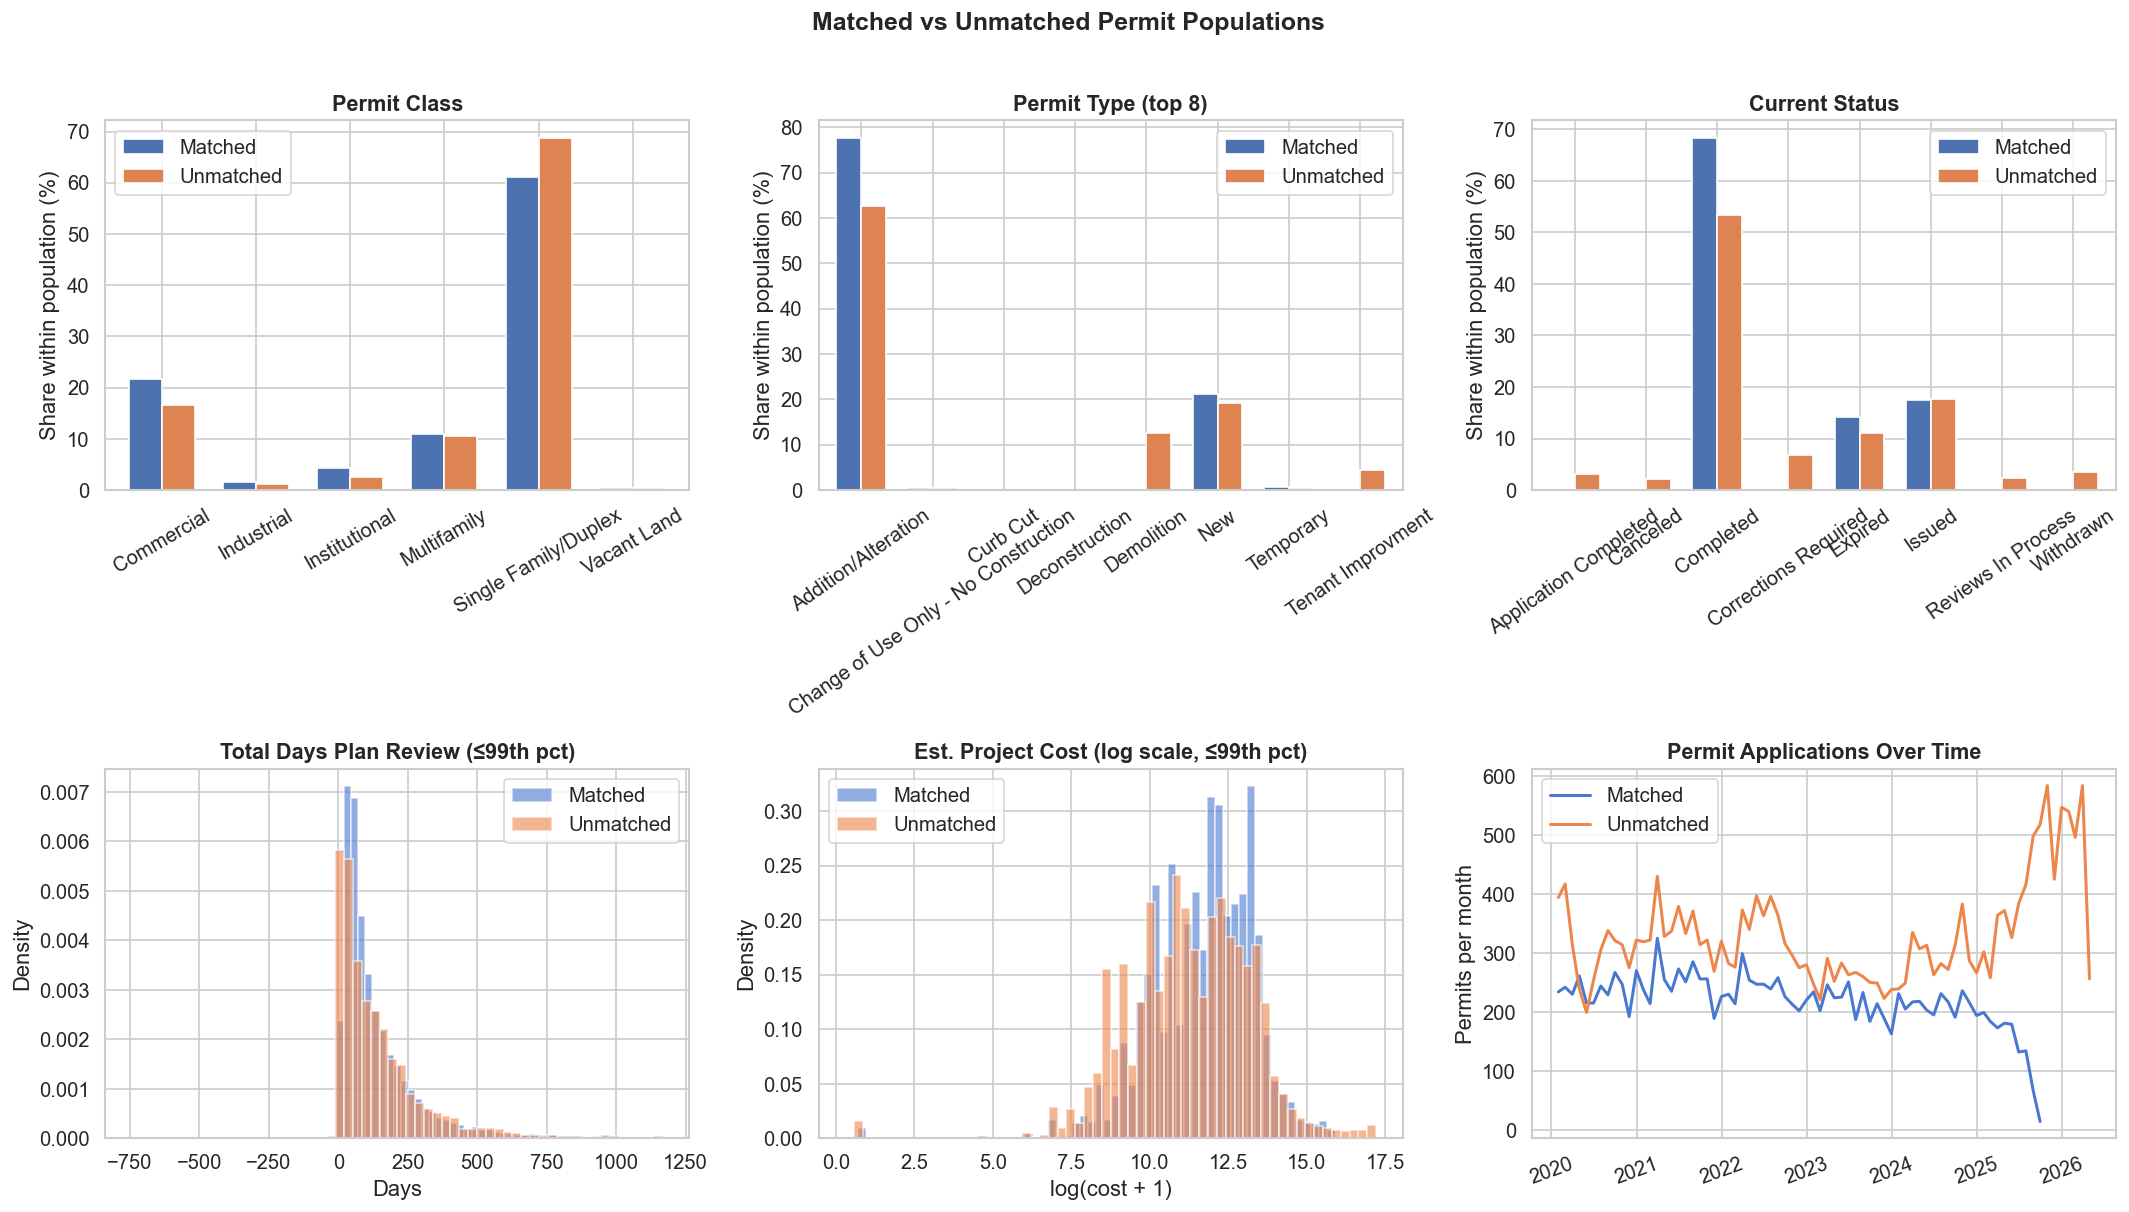


── totaldaysplanreview: matched vs unmatched ────────────────────────────

  Matched (n=15,066)
    mean   : 149.5 days
    median : 90.0 days
    p75    : 184.0 days
    p90    : 329.0 days
    p99    : 939.4 days

  Unmatched (n=7,746)
    mean   : 159.8 days
    median : 92.0 days
    p75    : 200.8 days
    p90    : 371.5 days
    p99    : 1168.0 days

── estprojectcost: matched vs unmatched ─────────────────────────────────

  Matched (n=15,022)
    median : $150,000
    mean   : $502,378
    p90    : $735,226

  Unmatched (n=24,473)
    median : $85,000
    mean   : $1,268,275
    p90    : $800,000


In [11]:
# ── Cell 10: Matched vs Unmatched Population Comparison ──────────────────────
# Goal: determine whether matched permits are systematically skewed by
# permit class, type, or timeline relative to the full population.
# This informs whether a matched-only model would generalize.

matched['population']   = 'Matched'
unmatched['population'] = 'Unmatched'
combined = pd.concat([matched, unmatched], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Matched vs Unmatched Permit Populations', fontsize=15, fontweight='bold', y=1.01)

# ── 1. permitclass ────────────────────────────────────────────────────────────
ax = axes[0, 0]
pc = (combined.groupby(['permitclass', 'population'])
               .size()
               .reset_index(name='count'))
pc['share'] = pc.groupby('population')['count'].transform(lambda x: x / x.sum() * 100)
pivot_pc = pc.pivot(index='permitclass', columns='population', values='share').fillna(0)
pivot_pc.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.7)
ax.set_title('Permit Class')
ax.set_ylabel('Share within population (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='')

# ── 2. permittypedesc ─────────────────────────────────────────────────────────
ax = axes[0, 1]
top_types = combined['permittypedesc'].value_counts().head(8).index
pt = (combined[combined['permittypedesc'].isin(top_types)]
      .groupby(['permittypedesc', 'population'])
      .size()
      .reset_index(name='count'))
pt['share'] = pt.groupby('population')['count'].transform(lambda x: x / x.sum() * 100)
pivot_pt = pt.pivot(index='permittypedesc', columns='population', values='share').fillna(0)
pivot_pt.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.7)
ax.set_title('Permit Type (top 8)')
ax.set_ylabel('Share within population (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='')

# ── 3. statuscurrent ─────────────────────────────────────────────────────────
ax = axes[0, 2]
top_status = combined['statuscurrent'].value_counts().head(8).index
sc = (combined[combined['statuscurrent'].isin(top_status)]
      .groupby(['statuscurrent', 'population'])
      .size()
      .reset_index(name='count'))
sc['share'] = sc.groupby('population')['count'].transform(lambda x: x / x.sum() * 100)
pivot_sc = sc.pivot(index='statuscurrent', columns='population', values='share').fillna(0)
pivot_sc.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.7)
ax.set_title('Current Status')
ax.set_ylabel('Share within population (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='')

# ── 4. totaldaysplanreview distribution ───────────────────────────────────────
ax = axes[1, 0]
for pop, grp in combined.groupby('population'):
    vals = grp['totaldaysplanreview'].dropna()
    vals = vals[vals <= vals.quantile(0.99)]  # clip extreme outliers for viz
    ax.hist(vals, bins=60, alpha=0.6, label=pop, density=True)
ax.set_title('Total Days Plan Review (≤99th pct)')
ax.set_xlabel('Days')
ax.set_ylabel('Density')
ax.legend(title='')

# ── 5. estprojectcost distribution ───────────────────────────────────────────
ax = axes[1, 1]
for pop, grp in combined.groupby('population'):
    vals = grp['estprojectcost'].dropna()
    vals = vals[(vals > 0) & (vals <= vals.quantile(0.99))]
    ax.hist(np.log1p(vals), bins=60, alpha=0.6, label=pop, density=True)
ax.set_title('Est. Project Cost (log scale, ≤99th pct)')
ax.set_xlabel('log(cost + 1)')
ax.set_ylabel('Density')
ax.legend(title='')

# ── 6. applieddate over time ──────────────────────────────────────────────────
ax = axes[1, 2]
for pop, grp in combined.groupby('population'):
    monthly = grp.set_index('applieddate').resample('ME').size()
    ax.plot(monthly.index, monthly.values, label=pop, linewidth=1.8)
ax.set_title('Permit Applications Over Time')
ax.set_xlabel('')
ax.set_ylabel('Permits per month')
ax.legend(title='')
ax.tick_params(axis='x', rotation=20)

# ── Cell 10a: Create output directory ────────────────────────────────────────
import os
os.makedirs('output', exist_ok=True)
print("output/ directory created ✓")
plt.tight_layout()
plt.savefig('output/matched_vs_unmatched.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Summary stats comparison ──────────────────────────────────────────────────
print("\n── totaldaysplanreview: matched vs unmatched ────────────────────────────")
for pop, grp in combined.groupby('population'):
    vals = grp['totaldaysplanreview'].dropna()
    print(f"\n  {pop} (n={len(vals):,})")
    print(f"    mean   : {vals.mean():.1f} days")
    print(f"    median : {vals.median():.1f} days")
    print(f"    p75    : {vals.quantile(.75):.1f} days")
    print(f"    p90    : {vals.quantile(.90):.1f} days")
    print(f"    p99    : {vals.quantile(.99):.1f} days")

print("\n── estprojectcost: matched vs unmatched ─────────────────────────────────")
for pop, grp in combined.groupby('population'):
    vals = grp['estprojectcost'].dropna()
    vals = vals[vals > 0]
    print(f"\n  {pop} (n={len(vals):,})")
    print(f"    median : ${vals.median():,.0f}")
    print(f"    mean   : ${vals.mean():,.0f}")
    print(f"    p90    : ${vals.quantile(.90):,.0f}")

In [12]:
# ── Cell 11: df_comments Coverage Investigation ───────────────────────────────
# Goal: determine whether df_comments follows the same pattern as df_review —
# i.e. whether comments are only present for in-process permits or whether
# approved/completed permits also retain comment history.

comments_permnums  = set(df_comments['permitnum'].unique())
permits_permnums   = set(df_permits['permitnum'].unique())
review_permnums    = set(df_review['permitnum'].unique())

# ── 1. Basic overlap ──────────────────────────────────────────────────────────
in_permits  = comments_permnums & permits_permnums
in_review   = comments_permnums & review_permnums
in_all_three = comments_permnums & permits_permnums & review_permnums
comments_only = comments_permnums - permits_permnums - review_permnums

print("── Comment permit coverage ───────────────────────────────────────────────")
print(f"  Unique permits in df_comments                    : {len(comments_permnums):,}")
print(f"  Comments permits also in df_permits              : {len(in_permits):,}  ({len(in_permits)/len(comments_permnums)*100:.1f}%)")
print(f"  Comments permits also in df_review               : {len(in_review):,}  ({len(in_review)/len(comments_permnums)*100:.1f}%)")
print(f"  Comments permits in all three datasets           : {len(in_all_three):,}  ({len(in_all_three)/len(comments_permnums)*100:.1f}%)")
print(f"  Comments permits in neither permits nor review   : {len(comments_only):,}")

# ── 2. Status breakdown of permits that have comments ────────────────────────
print("\n── Status of permits that have comments ─────────────────────────────────")
has_comments = df_permits[df_permits['permitnum'].isin(comments_permnums)]
no_comments  = df_permits[~df_permits['permitnum'].isin(comments_permnums)]

print(f"\n  Permits WITH comments (n={len(has_comments):,})")
print(has_comments['statuscurrent'].value_counts(normalize=True).mul(100).round(1).to_string())

print(f"\n  Permits WITHOUT comments (n={len(no_comments):,})")
print(no_comments['statuscurrent'].value_counts(normalize=True).mul(100).round(1).to_string())

# ── 3. Do comments-only permits skew toward in-process statuses? ──────────────
print("\n── permitclass: with vs without comments ────────────────────────────────")
print(f"\n  WITH comments")
print(has_comments['permitclass'].value_counts(normalize=True).mul(100).round(1).to_string())
print(f"\n  WITHOUT comments")
print(no_comments['permitclass'].value_counts(normalize=True).mul(100).round(1).to_string())

# ── 4. Timeline comparison: with vs without comments ─────────────────────────
print("\n── totaldaysplanreview: with vs without comments ────────────────────────")
for label, grp in [('With comments', has_comments), ('Without comments', no_comments)]:
    vals = grp['totaldaysplanreview'].dropna()
    print(f"\n  {label} (n={len(vals):,})")
    print(f"    mean   : {vals.mean():.1f} days")
    print(f"    median : {vals.median():.1f} days")
    print(f"    p75    : {vals.quantile(.75):.1f} days")
    print(f"    p90    : {vals.quantile(.90):.1f} days")

# ── 5. Cross-tab: comments vs review presence ─────────────────────────────────
print("\n── Cross-tab: comment presence vs review presence ───────────────────────")
df_permits['has_review']   = df_permits['permitnum'].isin(review_permnums)
df_permits['has_comments'] = df_permits['permitnum'].isin(comments_permnums)

ct = pd.crosstab(
    df_permits['has_review'],
    df_permits['has_comments'],
    margins=True,
    margins_name='Total'
)
ct.index   = ['No Review Records', 'Has Review Records', 'Total']
ct.columns = ['No Comments', 'Has Comments', 'Total']
print(ct.to_string())

── Comment permit coverage ───────────────────────────────────────────────
  Unique permits in df_comments                    : 707
  Comments permits also in df_permits              : 697  (98.6%)
  Comments permits also in df_review               : 690  (97.6%)
  Comments permits in all three datasets           : 690  (97.6%)
  Comments permits in neither permits nor review   : 10

── Status of permits that have comments ─────────────────────────────────

  Permits WITH comments (n=697)
statuscurrent
Issued                   70.2
Completed                28.8
Inspections Completed     0.7
Withdrawn                 0.3

  Permits WITHOUT comments (n=39,486)
statuscurrent
Completed                    57.9
Issued                       16.2
Expired                      12.1
Corrections Required          4.1
Withdrawn                     2.1
Application Completed         1.9
Reviews In Process            1.4
Canceled                      1.3
Awaiting Information          1.2
Ready for Iss

── Target variable: totaldaysplanreview ─────────────────────────────────
  Total permits          : 40,183
  Non-null               : 22,812  (56.8%)
  Null                   : 17,371  (43.2%)

── Status of permits where totaldaysplanreview is null ──────────────────
statuscurrent
Completed                    9060
Expired                      2035
Corrections Required         1619
Issued                       1584
Withdrawn                     829
Application Completed         742
Reviews In Process            564
Canceled                      498
Awaiting Information          163
Ready for Issuance            153
Inspections Completed          55
Reviews Completed              21
Closed                         18
Additional Info Requested      10
Phase Issued                    7
Corrections Submitted           7
Ready for Intake                3
Scheduled                       1
Denied                          1
Initiated                       1

── Descriptive statistics ──────────

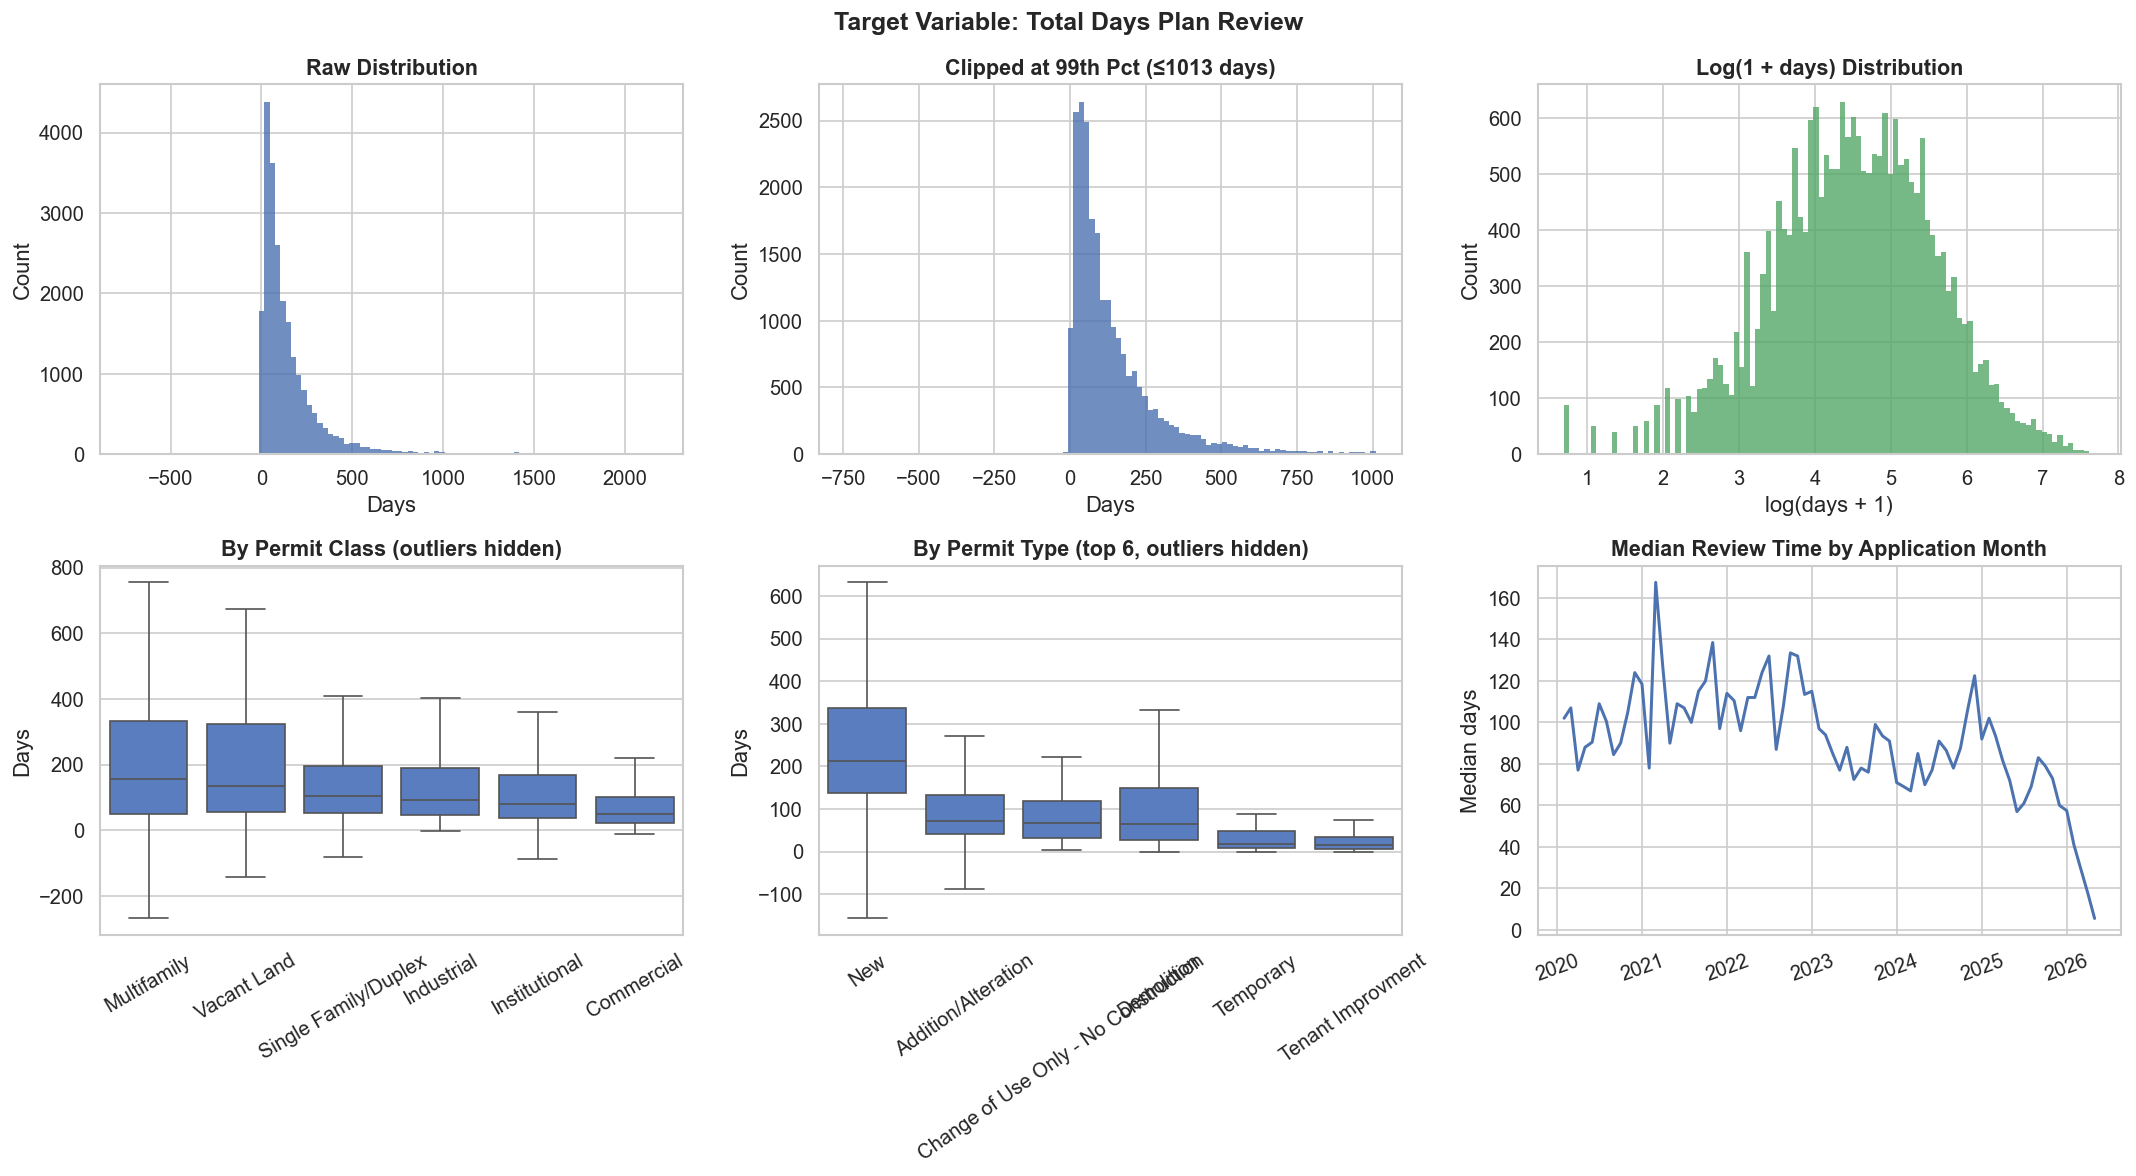

In [13]:
# ── Cell 12: Target Variable Analysis — totaldaysplanreview ──────────────────
# Goal: understand the distribution, nulls, outliers, and transformation
# needs of our primary target variable before any modeling decisions.

target = df_permits['totaldaysplanreview'].dropna()
target_all = df_permits['totaldaysplanreview']

# ── 1. Null breakdown ─────────────────────────────────────────────────────────
null_count = target_all.isna().sum()
null_pct   = target_all.isna().mean() * 100

print("── Target variable: totaldaysplanreview ─────────────────────────────────")
print(f"  Total permits          : {len(target_all):,}")
print(f"  Non-null               : {len(target):,}  ({100-null_pct:.1f}%)")
print(f"  Null                   : {null_count:,}  ({null_pct:.1f}%)")

# ── 2. Why are values null? — status of null permits ─────────────────────────
print("\n── Status of permits where totaldaysplanreview is null ──────────────────")
null_permits = df_permits[target_all.isna()]
print(null_permits['statuscurrent'].value_counts().to_string())

# ── 3. Descriptive stats ──────────────────────────────────────────────────────
print("\n── Descriptive statistics ───────────────────────────────────────────────")
percentiles = [.05, .10, .25, .50, .75, .90, .95, .99]
desc = target.describe(percentiles=percentiles)
print(desc.to_string())
print(f"\n  Skewness : {target.skew():.3f}")
print(f"  Kurtosis : {target.excess_kurtosis() if hasattr(target, 'excess_kurtosis') else stats.kurtosis(target):.3f}")

# ── 4. How many permits are zero or negative? ─────────────────────────────────
print("\n── Edge cases ───────────────────────────────────────────────────────────")
print(f"  Zero days     : {(target == 0).sum():,}")
print(f"  Negative days : {(target < 0).sum():,}")
print(f"  < 7 days      : {(target < 7).sum():,}")
print(f"  > 730 days    : {(target > 730).sum():,}  (> 2 years)")
print(f"  > 1095 days   : {(target > 1095).sum():,}  (> 3 years)")

# ── 5. Distribution plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Target Variable: Total Days Plan Review', fontsize=15, fontweight='bold')

# Raw distribution
ax = axes[0, 0]
ax.hist(target, bins=100, color='#4C72B0', edgecolor='none', alpha=0.8)
ax.set_title('Raw Distribution')
ax.set_xlabel('Days')
ax.set_ylabel('Count')

# Clipped at 99th percentile
ax = axes[0, 1]
p99 = target.quantile(0.99)
ax.hist(target[target <= p99], bins=100, color='#4C72B0', edgecolor='none', alpha=0.8)
ax.set_title(f'Clipped at 99th Pct (≤{p99:.0f} days)')
ax.set_xlabel('Days')
ax.set_ylabel('Count')

# Log-transformed
ax = axes[0, 2]
log_target = np.log1p(target[target > 0])
ax.hist(log_target, bins=100, color='#55A868', edgecolor='none', alpha=0.8)
ax.set_title('Log(1 + days) Distribution')
ax.set_xlabel('log(days + 1)')
ax.set_ylabel('Count')

# Box plot by permit class
ax = axes[1, 0]
plot_df = df_permits[target_all.notna()].copy()
order = plot_df.groupby('permitclass')['totaldaysplanreview'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df, x='permitclass', y='totaldaysplanreview',
            order=order, ax=ax, fliersize=1,
            showfliers=False)
ax.set_title('By Permit Class (outliers hidden)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('Days')

# Box plot by permittypedesc
ax = axes[1, 1]
top_types = plot_df['permittypedesc'].value_counts().head(6).index
type_df = plot_df[plot_df['permittypedesc'].isin(top_types)]
order2 = type_df.groupby('permittypedesc')['totaldaysplanreview'].median().sort_values(ascending=False).index
sns.boxplot(data=type_df, x='permittypedesc', y='totaldaysplanreview',
            order=order2, ax=ax, fliersize=1, showfliers=False)
ax.set_title('By Permit Type (top 6, outliers hidden)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=35)
ax.set_ylabel('Days')

# Over time — median per month
ax = axes[1, 2]
monthly = (df_permits[target_all.notna()]
           .set_index('applieddate')
           .resample('ME')['totaldaysplanreview']
           .median())
ax.plot(monthly.index, monthly.values, linewidth=1.8, color='#4C72B0')
ax.set_title('Median Review Time by Application Month')
ax.set_xlabel('')
ax.set_ylabel('Median days')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
os.makedirs('output', exist_ok=True)
plt.savefig('output/target_variable_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
# ── Cell 13: Completed-Null Investigation + Modeling Population Definition ────
# Goal: understand the 9,060 completed permits missing totaldaysplanreview,
# then lock in the final clean modeling population with explicit criteria.

# ── 1. Completed permits: null vs non-null target ─────────────────────────────
completed = df_permits[df_permits['statuscurrent'] == 'Completed'].copy()
comp_null    = completed[completed['totaldaysplanreview'].isna()]
comp_notnull = completed[completed['totaldaysplanreview'].notna()]

print("── Completed permits: target null vs non-null ───────────────────────────")
print(f"  Completed with target value    : {len(comp_notnull):,}  ({len(comp_notnull)/len(completed)*100:.1f}%)")
print(f"  Completed missing target value : {len(comp_null):,}  ({len(comp_null)/len(completed)*100:.1f}%)")

# ── 2. Are null-completed permits systematically different? ───────────────────
print("\n── permitclass: completed null vs non-null ──────────────────────────────")
for label, grp in [('Non-null', comp_notnull), ('Null', comp_null)]:
    print(f"\n  {label} (n={len(grp):,})")
    print(grp['permitclass'].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n── permittypedesc: completed null vs non-null ───────────────────────────")
for label, grp in [('Non-null', comp_notnull), ('Null', comp_null)]:
    print(f"\n  {label} (n={len(grp):,})")
    print(grp['permittypedesc'].value_counts(normalize=True).mul(100).round(1).head(8).to_string())

print("\n── applieddate year: completed null vs non-null ─────────────────────────")
for label, grp in [('Non-null', comp_notnull), ('Null', comp_null)]:
    print(f"\n  {label}")
    print(grp['applieddate'].dt.year.value_counts().sort_index().to_string())

print("\n── estprojectcost: completed null vs non-null ───────────────────────────")
for label, grp in [('Non-null', comp_notnull), ('Null', comp_null)]:
    vals = grp['estprojectcost'].dropna()
    vals = vals[vals > 0]
    print(f"\n  {label} (n={len(vals):,})")
    print(f"    median : ${vals.median():,.0f}")
    print(f"    mean   : ${vals.mean():,.0f}")
    print(f"    p90    : ${vals.quantile(.90):,.0f}")

# ── 3. Define modeling population ─────────────────────────────────────────────
print("\n── Modeling population: exclusion criteria ──────────────────────────────")

excl_null     = df_permits['totaldaysplanreview'].isna()
excl_negative = df_permits['totaldaysplanreview'] < 0
excl_zero     = df_permits['totaldaysplanreview'] == 0
excl_extreme  = df_permits['totaldaysplanreview'] > 1095  # > 3 years

print(f"  Null target                    : {excl_null.sum():,}")
print(f"  Negative target                : {excl_negative.sum():,}")
print(f"  Zero target                    : {excl_zero.sum():,}")
print(f"  Extreme outliers (> 3 years)   : {excl_extreme.sum():,}")
print(f"  (note: extreme subset of non-null, not additive)")

excl_any = excl_null | excl_negative | excl_zero | excl_extreme
df_model = df_permits[~excl_any].copy()

print(f"\n  Starting population            : {len(df_permits):,}")
print(f"  Excluded                       : {excl_any.sum():,}")
print(f"  Final modeling population      : {len(df_model):,}")

# ── 4. Final population sanity check ─────────────────────────────────────────
print("\n── Final modeling population: sanity check ──────────────────────────────")
print(f"  target min    : {df_model['totaldaysplanreview'].min():.0f} days")
print(f"  target max    : {df_model['totaldaysplanreview'].max():.0f} days")
print(f"  target median : {df_model['totaldaysplanreview'].median():.0f} days")
print(f"  target mean   : {df_model['totaldaysplanreview'].mean():.1f} days")

print("\n── permitclass distribution in modeling population ──────────────────────")
print(df_model['permitclass'].value_counts().to_string())

print("\n── statuscurrent distribution in modeling population ────────────────────")
print(df_model['statuscurrent'].value_counts().to_string())

print("\n── applieddate year distribution in modeling population ─────────────────")
print(df_model['applieddate'].dt.year.value_counts().sort_index().to_string())

── Completed permits: target null vs non-null ───────────────────────────
  Completed with target value    : 14,006  (60.7%)
  Completed missing target value : 9,060  (39.3%)

── permitclass: completed null vs non-null ──────────────────────────────

  Non-null (n=14,006)
permitclass
Single Family/Duplex    57.8
Commercial              23.5
Multifamily             12.1
Institutional            4.8
Industrial               1.4
Vacant Land              0.4

  Null (n=9,060)
permitclass
Single Family/Duplex    80.2
Commercial              11.5
Multifamily              6.1
Institutional            1.8
Industrial               0.4
Vacant Land              0.0

── permittypedesc: completed null vs non-null ───────────────────────────

  Non-null (n=14,006)
permittypedesc
Addition/Alteration                     60.8
New                                     23.9
Demolition                               8.7
Tenant Improvment                        5.6
Temporary                                0.6

In [16]:
# ── Cell 14: Feature Exploration Within Modeling Population ──────────────────
# Goal: assess all candidate predictor variables — distributions, cardinality,
# null rates, and preliminary signal vs target — within df_model specifically.

# ── 1. Candidate feature inventory ───────────────────────────────────────────
cat_features = [
    'permitclass', 'permitclassmapped', 'permittypemapped', 'permittypedesc',
    'statuscurrent', 'housingcategory', 'zoning', 'dwellingunittype',
    'dependentbuilding'
]

num_features = [
    'estprojectcost', 'housingunits', 'housingunitsadded', 'housingunitsremoved',
    'numberreviewcycles', 'daysoutcorrections', 'daysinitialplanreview',
    'daysplanreviewcity', 'daysissuepermitcity', 'latitude', 'longitude'
]

date_derived = ['applieddate']  # will derive year, month, quarter, dayofweek

print("── Feature inventory ─────────────────────────────────────────────────────")
print(f"  Categorical : {len(cat_features)}")
print(f"  Numeric     : {len(num_features)}")
print(f"  Date-derived: {len(date_derived)}")
print(f"  Modeling pop: {len(df_model):,} rows")

# ── 2. Categorical feature audit ─────────────────────────────────────────────
print("\n── Categorical features: nulls + cardinality ────────────────────────────")
print(f"  {'Feature':<25} {'Null%':>7} {'N Unique':>10} {'Top value':<30} {'Top%':>6}")
print("  " + "─" * 82)
for col in cat_features:
    if col not in df_model.columns:
        print(f"  {col:<25} NOT IN df_model")
        continue
    null_pct  = df_model[col].isna().mean() * 100
    n_unique  = df_model[col].nunique()
    top_val   = df_model[col].value_counts().index[0] if n_unique > 0 else 'N/A'
    top_pct   = df_model[col].value_counts(normalize=True).iloc[0] * 100
    print(f"  {col:<25} {null_pct:>6.1f}% {n_unique:>10} {str(top_val):<30} {top_pct:>5.1f}%")

# ── 3. Numeric feature audit ──────────────────────────────────────────────────
print("\n── Numeric features: nulls + basic stats ────────────────────────────────")
print(f"  {'Feature':<28} {'Null%':>7} {'Min':>10} {'Median':>10} {'Mean':>10} {'Max':>12}")
print("  " + "─" * 85)
for col in num_features:
    if col not in df_model.columns:
        print(f"  {col:<28} NOT IN df_model")
        continue
    null_pct = df_model[col].isna().mean() * 100
    vals     = df_model[col].dropna()
    print(f"  {col:<28} {null_pct:>6.1f}% {vals.min():>10.1f} {vals.median():>10.1f} "
          f"{vals.mean():>10.1f} {vals.max():>12.1f}")

# ── 4. Correlation of numeric features with target ───────────────────────────
print("\n── Numeric feature correlation with totaldaysplanreview ─────────────────")
log_target = np.log1p(df_model['totaldaysplanreview'])
correlations = {}
for col in num_features:
    if col not in df_model.columns:
        continue
    vals = df_model[[col, 'totaldaysplanreview']].dropna()
    if len(vals) < 100:
        continue
    r_raw, _  = stats.pearsonr(vals[col], vals['totaldaysplanreview'])
    log_vals  = np.log1p(df_model[[col]].join(log_target).dropna())
    r_log, _  = stats.pearsonr(
        np.log1p(df_model[col].dropna()),
        log_target[df_model[col].notna()]
    ) if df_model[col].notna().sum() > 100 else (np.nan, None)
    correlations[col] = {'r_raw': r_raw, 'r_log': r_log}

corr_df = pd.DataFrame(correlations).T.sort_values('r_raw', key=abs, ascending=False)
print(corr_df.round(3).to_string())

# ── 5. Median target by categorical feature ───────────────────────────────────
print("\n── Median totaldaysplanreview by categorical feature ────────────────────")
for col in cat_features:
    if col not in df_model.columns:
        continue
    n_unique = df_model[col].nunique()
    if n_unique > 20:
        print(f"\n  {col} — {n_unique} unique values, showing top 10 by count")
        top_cats = df_model[col].value_counts().head(10).index
        grp = df_model[df_model[col].isin(top_cats)]
    else:
        print(f"\n  {col} — {n_unique} unique values")
        grp = df_model.copy()
    summary = (grp.groupby(col)['totaldaysplanreview']
                  .agg(n='count', median='median', mean='mean')
                  .sort_values('median', ascending=False))
    print(summary.round(1).to_string())

# ── 6. Applied date features ──────────────────────────────────────────────────
print("\n── Applied date derived features vs target ──────────────────────────────")
df_model['app_year']    = df_model['applieddate'].dt.year
df_model['app_month']   = df_model['applieddate'].dt.month
df_model['app_quarter'] = df_model['applieddate'].dt.quarter

for col in ['app_year', 'app_month', 'app_quarter']:
    summary = (df_model.groupby(col)['totaldaysplanreview']
                       .agg(n='count', median='median')
                       .sort_index())
    print(f"\n  {col}")
    print(summary.to_string())

── Feature inventory ─────────────────────────────────────────────────────
  Categorical : 9
  Numeric     : 11
  Date-derived: 1
  Modeling pop: 22,423 rows

── Categorical features: nulls + cardinality ────────────────────────────
  Feature                     Null%   N Unique Top value                        Top%
  ──────────────────────────────────────────────────────────────────────────────────
  permitclass                  0.0%          6 Single Family/Duplex            59.3%
  permitclassmapped            0.0%          2 Residential                     71.0%
  permittypemapped             0.0%          3 Building                        89.3%
  permittypedesc               2.4%          8 Addition/Alteration             60.8%
  statuscurrent                0.0%         12 Completed                       61.7%
  housingcategory             31.4%          6 Middle Housing                  37.9%
  zoning                      17.0%        676 NR3                             22.6%
  

In [17]:
# ── Cell 15: Data Cleaning Within Modeling Population ────────────────────────
# Goal: fix data errors, drop 2026 incomplete permits, handle high-cardinality
# zoning, and prepare the clean feature set for engineering.
# We do NOT touch df_permits — all changes are to df_model only.

# ── 1. Drop 2026 permits (incomplete review cycles) ──────────────────────────
pre_drop = len(df_model)
df_model = df_model[df_model['app_year'] != 2026].copy()
print(f"── 2026 permits dropped: {pre_drop - len(df_model):,}  →  {len(df_model):,} remaining")

# ── 2. Fix negative housingunits ──────────────────────────────────────────────
neg_units = (df_model['housingunits'] < 0).sum()
df_model.loc[df_model['housingunits'] < 0, 'housingunits'] = np.nan
print(f"\n── housingunits: {neg_units} negative values → set to NaN")

# ── 3. Fix negative daysissuepermitcity ───────────────────────────────────────
neg_days = (df_model['daysissuepermitcity'] < 0).sum()
df_model.loc[df_model['daysissuepermitcity'] < 0, 'daysissuepermitcity'] = np.nan
print(f"── daysissuepermitcity: {neg_days} negative values → set to NaN")

# ── 4. Fix zero estprojectcost → NaN (not a real cost) ───────────────────────
zero_cost = (df_model['estprojectcost'] == 0).sum()
df_model.loc[df_model['estprojectcost'] == 0, 'estprojectcost'] = np.nan
print(f"── estprojectcost: {zero_cost} zero values → set to NaN")

# ── 5. Cap daysoutcorrections at 99th percentile ─────────────────────────────
p99_doc = df_model['daysoutcorrections'].quantile(0.99)
extreme_doc = (df_model['daysoutcorrections'] > p99_doc).sum()
df_model.loc[df_model['daysoutcorrections'] > p99_doc, 'daysoutcorrections'] = p99_doc
print(f"── daysoutcorrections: {extreme_doc} values above p99 ({p99_doc:.0f} days) → capped")

# ── 6. Zoning family extraction ───────────────────────────────────────────────
# Extract zone family prefix from raw zoning string (e.g. 'LR3' → 'LR')
def extract_zone_family(z):
    if pd.isna(z):
        return 'Unknown'
    z = str(z).strip().upper()
    # known families
    for prefix in ['NR', 'LR', 'MR', 'HR', 'SF', 'NC', 'C1', 'C2', 'SM',
                   'IDM', 'IB', 'IG', 'IC', 'DH', 'DMC', 'DOC', 'MIO',
                   'PMM', 'SCM', 'PSM', 'ISRD']:
        if z.startswith(prefix):
            return prefix
    return 'Other'

df_model['zone_family'] = df_model['zoning'].apply(extract_zone_family)

print(f"\n── Zoning family distribution ───────────────────────────────────────────")
zf = df_model['zone_family'].value_counts()
print(zf.to_string())

# ── 7. Null strategy for high-null categoricals ───────────────────────────────
# Fill nulls with explicit 'Unknown' category rather than dropping rows
for col in ['housingcategory', 'dwellingunittype', 'permittypedesc']:
    null_count = df_model[col].isna().sum()
    df_model[col] = df_model[col].fillna('Unknown')
    print(f"\n── {col}: {null_count} nulls → filled with 'Unknown'")

# ── 8. Log-transform skewed numerics ─────────────────────────────────────────
df_model['log_estprojectcost']   = np.log1p(df_model['estprojectcost'])
df_model['log_housingunitsadded'] = np.log1p(df_model['housingunitsadded'])
df_model['log_target']           = np.log1p(df_model['totaldaysplanreview'])

print(f"\n── Log transforms created: log_estprojectcost, log_housingunitsadded, log_target")

# ── 9. Final clean population summary ────────────────────────────────────────
print(f"\n── Final clean modeling population ──────────────────────────────────────")
print(f"  Rows                  : {len(df_model):,}")
print(f"  Target range          : {df_model['totaldaysplanreview'].min():.0f} – "
      f"{df_model['totaldaysplanreview'].max():.0f} days")
print(f"  Target median         : {df_model['totaldaysplanreview'].median():.0f} days")
print(f"  log_target skewness   : {df_model['log_target'].skew():.3f}")
print(f"  raw target skewness   : {df_model['totaldaysplanreview'].skew():.3f}")

# ── 10. Null audit on final feature set ──────────────────────────────────────
feature_cols = [
    'permitclass', 'permittypedesc', 'dwellingunittype', 'housingcategory',
    'zone_family', 'log_estprojectcost', 'log_housingunitsadded',
    'dependentbuilding', 'app_year', 'app_month', 'app_quarter',
    'latitude', 'longitude', 'log_target'
]

print(f"\n── Null audit on final feature set ──────────────────────────────────────")
print(f"  {'Feature':<28} {'Null%':>7}  {'Null n':>8}")
print("  " + "─" * 48)
for col in feature_cols:
    if col in df_model.columns:
        n_null   = df_model[col].isna().sum()
        pct_null = df_model[col].isna().mean() * 100
        print(f"  {col:<28} {pct_null:>6.1f}%  {n_null:>8,}")

── 2026 permits dropped: 374  →  22,049 remaining

── housingunits: 1136 negative values → set to NaN
── daysissuepermitcity: 1 negative values → set to NaN
── estprojectcost: 447 zero values → set to NaN
── daysoutcorrections: 220 values above p99 (1005 days) → capped

── Zoning family distribution ───────────────────────────────────────────
zone_family
NR         6274
SF         3736
Unknown    3442
LR         2679
NC         1632
Other      1430
SM          488
IG          417
MIO         377
C1          296
DOC         284
DMC         269
MR          149
IC          139
PSM         132
C2          104
DH           58
HR           54
IDM          37
IB           29
PMM          23

── housingcategory: 6878 nulls → filled with 'Unknown'

── dwellingunittype: 3297 nulls → filled with 'Unknown'

── permittypedesc: 515 nulls → filled with 'Unknown'

── Log transforms created: log_estprojectcost, log_housingunitsadded, log_target

── Final clean modeling population ──────────────────────

In [19]:
# ── Cell 16: Geographic Distribution of Permit Approval Times ────────────────
# Goal: scatter map of totaldaysplanreview across Seattle,
# colored red-to-green by approval time, clipped to Seattle bounding box.

import plotly.express as px

# ── Seattle bounding box ──────────────────────────────────────────────────────
SEATTLE_LAT_MIN, SEATTLE_LAT_MAX = 47.49, 47.735
SEATTLE_LON_MIN, SEATTLE_LON_MAX = -122.44, -122.24
SEATTLE_CENTER_LAT = (SEATTLE_LAT_MIN + SEATTLE_LAT_MAX) / 2
SEATTLE_CENTER_LON = (SEATTLE_LON_MIN + SEATTLE_LON_MAX) / 2

# ── Build map dataframe ───────────────────────────────────────────────────────
map_df = df_model[['latitude', 'longitude', 'totaldaysplanreview',
                    'permittypedesc', 'permitclass',
                    'housingcategory', 'app_year']].dropna().copy()

map_df['latitude']  = pd.to_numeric(map_df['latitude'],  errors='coerce')
map_df['longitude'] = pd.to_numeric(map_df['longitude'], errors='coerce')
map_df = map_df.dropna()

# Clip to Seattle bounding box
map_df = map_df[
    map_df['latitude'].between(SEATTLE_LAT_MIN, SEATTLE_LAT_MAX) &
    map_df['longitude'].between(SEATTLE_LON_MIN, SEATTLE_LON_MAX)
]

print(f"Points within Seattle bounding box: {len(map_df):,}")

if map_df.empty:
    print('No points within Seattle bounding box — check lat/lon values.')
else:
    sample_n   = min(10_000, len(map_df))
    map_sample = map_df.sample(sample_n, random_state=SEED)

    fig = px.scatter_mapbox(
        map_sample,
        lat='latitude',
        lon='longitude',
        color='totaldaysplanreview',
        color_continuous_scale='RdYlGn_r',
        hover_data={
            'permittypedesc'      : True,
            'permitclass'         : True,
            'housingcategory'     : True,
            'app_year'            : True,
            'totaldaysplanreview' : True,
            'latitude'            : False,
            'longitude'           : False
        },
        mapbox_style='carto-positron',
        center={'lat': SEATTLE_CENTER_LAT, 'lon': SEATTLE_CENTER_LON},
        zoom=11,
        opacity=0.55,
        size_max=6,
        title=f'Permit Approval Times Across Seattle (n={sample_n:,})'
    )

    fig.update_layout(
        width=700,
        height=860,
        margin=dict(l=0, r=0, t=40, b=0),
        coloraxis_colorbar=dict(
            title='Days',
            thickness=14,
            len=0.6,
            tickvals=[0, 200, 400, 600, 800, 1000],
        )
    )

    fig.show()
    fig.write_html('output/permit_map.html')
    print(f'Map rendered: {len(map_sample):,} permits within Seattle bounds.')
    print('Saved to output/permit_map.html')

Points within Seattle bounding box: 22,017


Map rendered: 10,000 permits within Seattle bounds.
Saved to output/permit_map.html
